# Importação de Bibliotecas

In [ ]:
import cv2 #leitura e manipulação de imagens
from sklearn.model_selection import train_test_split # d ivisão entre treino e teste
from sklearn.preprocessing import StandardScaler # normalização dos dados
from sklearn.linear_model import LogisticRegression # modelo de regressão logística
from sklearn.neighbors import KNeighborsClassifier # modelo KNN
from sklearn.neural_network import MLPClassifier # modelo de rede neural simples
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score #avaliação dos modelos.
from sklearn.preprocessing import MinMaxScaler #normalização alternativa


# Vetorização comum de imagens - TREINO / TESTE

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from PIL import Image
import os # manipulação de diretórios e caminhos de arquivos.
import pandas as pd #m anipulação e análise de dados em DataFrames.
import numpy as np #operações matemáticas e manipulação de arrays.

In [ ]:
# funçao para vetorizar uma imagem
def vetorizar_imagem(caminho_imagem, tamanho=(64, 64)):
    imagem = Image.open(caminho_imagem).resize(tamanho).convert('RGB')
    vetor = np.array(imagem).flatten()
    return vetor

In [ ]:
# função para gerar DataFrame com vetores e labels
def gerar_dataset_vetorizado(diretorio_base, tamanho=(64, 64)):
    dados = []
    labels = []
    classes = os.listdir(diretorio_base)
    for classe in classes:
        pasta_classe = os.path.join(diretorio_base, classe)
        for nome_arquivo in os.listdir(pasta_classe):
            caminho_imagem = os.path.join(pasta_classe, nome_arquivo)
            if caminho_imagem.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    vetor = vetorizar_imagem(caminho_imagem, tamanho)
                    dados.append(vetor)
                    labels.append(classe)
                except Exception as e:
                    print(f"Erro ao processar {caminho_imagem}: {e}")
    df = pd.DataFrame(dados)
    df['label'] = labels
    return df


In [ ]:
caminho_treino = "/content/drive/MyDrive/visão computacional/treino"
caminho_teste = "/content/drive/MyDrive/visão computacional/teste"

df_treino = gerar_dataset_vetorizado(caminho_treino)
df_teste = gerar_dataset_vetorizado(caminho_teste)

# salvando CSVs
df_treino.to_csv('/content/drive/MyDrive/visão computacional/dataset_treino.csv', index=False)
df_teste.to_csv('/content/drive/MyDrive/visão computacional/dataset_teste.csv', index=False)

# Carregamento da vetorização salva no drive

* Carregamento de dados ja vetorizados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df_treino = pd.read_csv('/content/drive/MyDrive/visão computacional/dataset_treino.csv')
df_teste = pd.read_csv('/content/drive/MyDrive/visão computacional/dataset_teste.csv')

# Separação de Atributos e Rótulos




In [ ]:
atributos_treino = df_treino.drop('label', axis=1).values
rótulos_treino = df_treino['label'].values

atributos_teste = df_teste.drop('label', axis=1).values
rótulos_teste = df_teste['label'].values


# Normalização (Padronização Z-score)



*   Cada pixel tem de 0 a 255 valores - [34, 200, 128, 255]
*   Normalizado fica entre 0 e 1 - [0.12, 0.40, 0.79]



In [ ]:
scaler = MinMaxScaler()# escala entre 0 e 1
atributos_treino_normalizado = scaler.fit_transform(atributos_treino)#a prende (fit) o min e max dos dados e normaliza.	Nos dados de treino.
atributos_teste_normalizado = scaler.transform(atributos_teste)#  o min e max já estão aprendidos ele só normaliza.	Nos dados de teste ou novos dados.

# Treinamento e Avaliação dos Modelos



* 0 = Gatos / 1=Cachorros

Treinando: Regressão Logística
Relatório de Classificação — Regressão Logística
              precision    recall  f1-score   support

   cachorros       0.57      0.55      0.56      1012
       gatos       0.57      0.59      0.58      1011

    accuracy                           0.57      2023
   macro avg       0.57      0.57      0.57      2023
weighted avg       0.57      0.57      0.57      2023



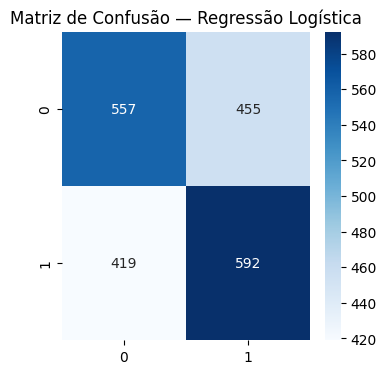

Treinando: KNN
Relatório de Classificação — KNN
              precision    recall  f1-score   support

   cachorros       0.61      0.43      0.50      1012
       gatos       0.56      0.72      0.63      1011

    accuracy                           0.58      2023
   macro avg       0.58      0.58      0.57      2023
weighted avg       0.58      0.58      0.57      2023



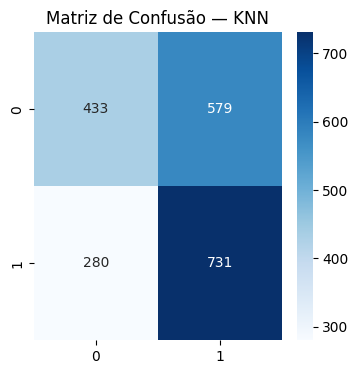

Treinando: Rede Neural (MLP)
Relatório de Classificação — Rede Neural (MLP)
              precision    recall  f1-score   support

   cachorros       0.73      0.35      0.47      1012
       gatos       0.57      0.87      0.69      1011

    accuracy                           0.61      2023
   macro avg       0.65      0.61      0.58      2023
weighted avg       0.65      0.61      0.58      2023



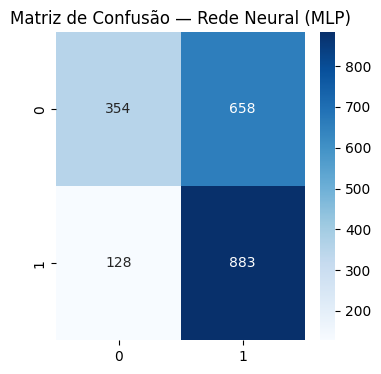

In [ ]:
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, C=0.5, solver='lbfgs'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Rede Neural (MLP)': MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=1000, activation='relu')
}


for nome_modelo, modelo in modelos.items():
    print(f"Treinando: {nome_modelo}")
    modelo.fit(atributos_treino_normalizado, rótulos_treino)

    previsoes = modelo.predict(atributos_teste_normalizado)

    print(f"Relatório de Classificação — {nome_modelo}")
    print(classification_report(rótulos_teste, previsoes))

    plt.figure(figsize=(4,4))
    sns.heatmap(confusion_matrix(rótulos_teste, previsoes), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão — {nome_modelo}")
    plt.show()


# Teste Pratico

In [ ]:
from joblib import dump

modelo = LogisticRegression(max_iter=1000, C=0.5, solver='lbfgs')
modelo.fit(atributos_treino_normalizado, rótulos_treino)

dump(modelo, '/content/drive/MyDrive/visão computacional/modelo_logistico_pixels.joblib')


['/content/drive/MyDrive/visão computacional/modelo_logistico_pixels.joblib']

In [ ]:
from joblib import load

modelo = load('/content/drive/MyDrive/visão computacional/modelo_logistico_pixels.joblib')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

caminho_novas_imagens = '/content/drive/MyDrive/visão computacional/teste pratico'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from PIL import Image
import os
import numpy as np

def vetorizar_imagem(caminho_imagem, tamanho=(64, 64)):
    imagem = Image.open(caminho_imagem).resize(tamanho).convert('RGB')
    vetor = np.array(imagem).flatten()
    return vetor

for arquivo in os.listdir(caminho_novas_imagens):
    if arquivo.lower().endswith(('.jpg', '.jpeg', '.png')):
        caminho_imagem = os.path.join(caminho_novas_imagens, arquivo)
        vetor = vetorizar_imagem(caminho_imagem)
        vetor_normalizado = scaler.transform([vetor])
        predicao = modelo.predict(vetor_normalizado)
        print(f"Imagem: {arquivo} → Predição: {predicao[0]}")


Imagem: download.jpg → Predição: cachorros
Imagem: download (1).jpg → Predição: cachorros
Imagem: download (2).jpg → Predição: gatos
Imagem: download (3).jpg → Predição: cachorros
Imagem: download (4).jpg → Predição: cachorros
Imagem: download (5).jpg → Predição: gatos
Imagem: download (6).jpg → Predição: cachorros
Imagem: download (7).jpg → Predição: cachorros
Imagem: images.jpg → Predição: gatos
